In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('train.csv')

print("Data berhasil di-load!")
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")

df.head()

Data berhasil di-load!
Jumlah baris: 891
Jumlah kolom: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Info data
print("="*50)
print("INFO DATA")
print("="*50)
df.info()

print("\n" + "="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)
df.describe()

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB

STATISTIK DESKRIPTIF

MISSING VALUES
survived         0
pclass           0
sex              0
age 

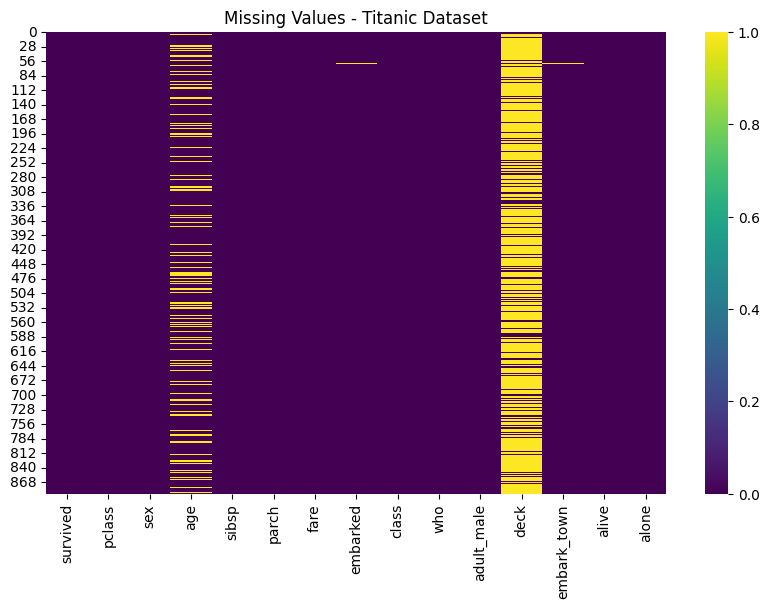

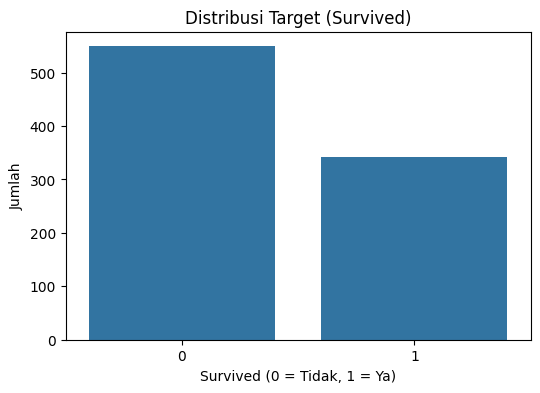

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title('Missing Values - Titanic Dataset')
plt.show()

# Distribusi target (Survived)
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)
plt.title('Distribusi Target (Survived)')
plt.xlabel('Survived (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Buat salinan data
df_clean = df.copy()

# 1. Drop kolom yang tidak berguna
df_clean.drop(['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'], axis=1, inplace=True)
print("Kolom yang di-drop: class, who, adult_male, deck, embark_town, alive, alone")
print(f"Kolom tersisa: {df_clean.columns.tolist()}")

# 2. Handle missing values
# Age: isi dengan median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Embarked: isi dengan modus (nilai paling sering muncul)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

print("\nMissing values setelah ditangani:")
print(df_clean.isnull().sum())

# 3. Encoding fitur kategorikal
# Sex: male=0, female=1
le_sex = LabelEncoder()
df_clean['sex'] = le_sex.fit_transform(df_clean['sex'])

# Embarked: S=0, C=1, Q=2
le_embarked = LabelEncoder()
df_clean['embarked'] = le_embarked.fit_transform(df_clean['embarked'])

print("\nData setelah encoding:")
print(df_clean.head())

Kolom yang di-drop: class, who, adult_male, deck, embark_town, alive, alone
Kolom tersisa: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Missing values setelah ditangani:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Data setelah encoding:
   survived  pclass  sex   age  sibsp  parch     fare  embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


In [7]:
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur (X) dan target (y)
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

# Scaling fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ubah kembali ke DataFrame agar lebih mudah dibaca
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df['survived'] = y.values

print("Data setelah scaling:")
print(X_scaled_df.head())

# Simpan data yang sudah siap preprocessing ke CSV
X_scaled_df.to_csv('titanic_preprocessed.csv', index=False)
print("\nData preprocessing disimpan ke 'titanic_preprocessed.csv'")

Data setelah scaling:
     pclass       sex       age     sibsp     parch      fare  embarked  \
0  0.827377  0.737695 -0.565736  0.432793 -0.473674 -0.502445  0.585954   
1 -1.566107 -1.355574  0.663861  0.432793 -0.473674  0.786845 -1.942303   
2  0.827377 -1.355574 -0.258337 -0.474545 -0.473674 -0.488854  0.585954   
3 -1.566107 -1.355574  0.433312  0.432793 -0.473674  0.420730  0.585954   
4  0.827377  0.737695  0.433312 -0.474545 -0.473674 -0.486337  0.585954   

   survived  
0         0  
1         1  
2         1  
3         1  
4         0  

Data preprocessing disimpan ke 'titanic_preprocessed.csv'
